# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset `ProblemB_dataset.h5`:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])


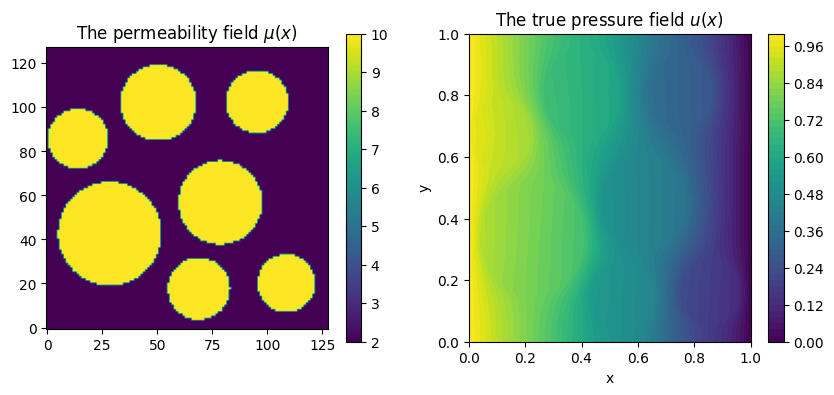

In [2]:
import numpy as np
import torch
import h5py
import matplotlib.pyplot as  plt

# ################################# The testing dataset
with h5py.File('Datasets\ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']), dtype=torch.float32) # Should not be used for training !!!
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)
#
def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]
    
    return mu_new.T

mu = fun_mu(x_test)

# ##################################
fig, axes = plt.subplots(1, 2, figsize=(10,4))
#
cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
axes[0].set_title(r'The permeability field $\mu(x)$')
plt.colorbar(cntr)
#
cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test, levels=50)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'The true pressure field $u(x)$')
plt.colorbar(cntr)
plt.show()

### Additional Imports and Device Setup

In [3]:
import torch
from torchsummary import summary
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader

from tqdm import trange

from scipy.interpolate import griddata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Use CUDA if available, else use CPU
dataType = torch.float32    # sets the PyTorch tensor type to 32-bit floating point

np.random.seed(1234)    # fixes NumPy’s random seed, reproducible result
torch.manual_seed(1234) # fixes PyTorch’s random seed, reproducible result

print(f"device: {device}")

device: cuda


### Grid and Collocation points

Size of test points: torch.Size([16384, 2])
Size of test solution: torch.Size([128, 128])
Size of mu field: torch.Size([128, 128])


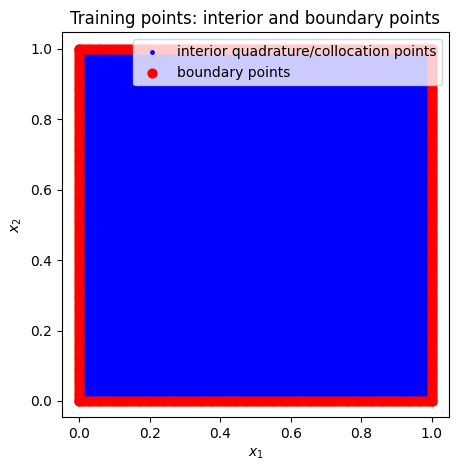

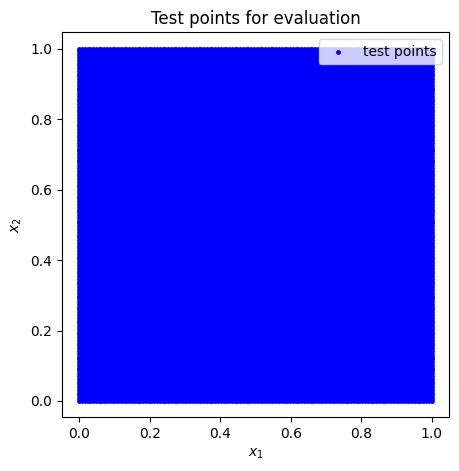

In [14]:
lb = [0., 0] 
ub = [1., 1.] 

n = 128         # To match the resolution of the given permeability field
nc = n**2       # number of collocation points

# --- The Boundary Points (x,y=0) and (x,y=1) ---
# Lower boundary
x_lw = np.vstack((
    np.linspace(lb[0], ub[0], n),
    lb[1] * np.ones(n)
)).T

# Upper boundary
x_up = np.vstack((
    np.linspace(lb[0], ub[0], n),
    ub[1] * np.ones(n)
)).T

# Left boundary
x_lt = np.vstack((
    lb[0] * np.ones(n),
    np.linspace(lb[1], ub[1], n)
)).T

# Right boundary
x_rt = np.vstack((
    ub[0] * np.ones(n),
    np.linspace(lb[1], ub[1], n)
)).T

# combine boundary points
x_bd_np = np.vstack((x_lw, x_up, x_lt, x_rt))
x_bd = torch.tensor(x_bd_np, dtype=dataType)

# --- The Collocation Points (x,y) ---
x = (np.arange(n) + 0.5) / n    # x-coordinates of the cell centers
y = (np.arange(n) + 0.5) / n    # y-coordinates of the cell centers

X, Y = np.meshgrid(x, y, indexing='ij')

x_in = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1)
x_in = torch.tensor(x_in, dtype=dataType)

# --- Test points from dataset, used only for evaluation ---
# Extract test data from dataset
with h5py.File('Datasets/ProblemB_dataset.h5', 'r') as file:
    x_test = np.array(file['x_test'])
    u_test = np.array(file['u_test'])
    mu_field = np.array(file['mu_field'])

x_test = torch.tensor(x_test, dtype=dataType)
u_test = torch.tensor(u_test, dtype=dataType)
mu_field = torch.tensor(mu_field, dtype=dataType)

print('Size of test points:', x_test.shape)
print('Size of test solution:', u_test.shape)
print('Size of mu field:', mu_field.shape)

# --- Plot 1: Training points ---
plt.figure(figsize=(5, 5))
plt.scatter(x_in.detach().cpu().numpy()[:, 0], x_in.detach().cpu().numpy()[:, 1], s=6, color='b', label='interior quadrature/collocation points')
plt.scatter(x_bd.detach().cpu().numpy()[:, 0], x_bd.detach().cpu().numpy()[:, 1], color='r', s=40, label='boundary points')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Training points: interior and boundary points')
plt.legend()
plt.axis('equal')
plt.show()

# --- Plot 2: Test points ---
plt.figure(figsize=(5, 5))
plt.scatter(x_test.detach().cpu().numpy()[:, 0], x_test.detach().cpu().numpy()[:, 1], s=6, color='b', label='test points')

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Test points for evaluation')
plt.legend()
plt.axis('equal')
plt.show()


### Test Function

### Multi-Layer Perceptron

### Loss Function

### Training

### Visualization